# Когортный анализ, RFM-сегментация и LTV proxy

## Цель ноутбука

Цель этого ноутбука — проанализировать удержание клиентов, повторные покупки, ценность клиентов и поведенческие сегменты в маркетплейсе Olist.

В этом анализе мы рассмотрим:

- повторные покупки;
- retention по когортам;
- RFM-сегментацию клиентов;
- LTV proxy на основе накопленного GMV за период наблюдения.

Важно: в проекте мы не считаем настоящий LTV, потому что в данных нет маржи, CAC, рекламных расходов и комиссии маркетплейса. Поэтому LTV используется как proxy-метрика: накопленный GMV клиента за доступный период наблюдения.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

In [3]:
orders_base = pd.read_csv("../data/processed/orders_base.csv")

orders_base.shape

(99441, 33)

In [4]:
orders_base.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'items_count',
 'products_count',
 'sellers_count',
 'product_revenue',
 'freight_value',
 'payment_value',
 'payment_installments',
 'payment_types_count',
 'payment_records_count',
 'review_score',
 'review_records_count',
 'first_review_creation_date',
 'last_review_answer_timestamp',
 'gmv',
 'order_value_with_freight',
 'delivery_days',
 'delivery_delay_days',
 'is_delivered',
 'has_review',
 'has_payment',
 'has_items']

## Подготовка данных для клиентского анализа

Для анализа повторных покупок, retention, RFM и LTV proxy важно правильно определить клиента.

В данных Olist есть два идентификатора:

- `customer_id` — идентификатор клиента внутри конкретного заказа;
- `customer_unique_id` — уникальный идентификатор покупателя.

Для анализа повторных покупок нужно использовать `customer_unique_id`, потому что один и тот же покупатель может иметь разные `customer_id` в разных заказах.

Также для расчёта клиентских метрик мы будем использовать только доставленные заказы, так как именно они отражают завершённые покупки.

In [5]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "first_review_creation_date",
    "last_review_answer_timestamp"
]

for column in date_columns:
    orders_base[column] = pd.to_datetime(orders_base[column], errors="coerce")

orders_delivered = orders_base.query("order_status == 'delivered'").copy()

orders_delivered.shape

(96478, 33)

In [6]:
customer_key_check = pd.Series({
    "orders": orders_delivered["order_id"].nunique(),
    "customer_id": orders_delivered["customer_id"].nunique(),
    "customer_unique_id": orders_delivered["customer_unique_id"].nunique(),
    "missing_customer_unique_id": orders_delivered["customer_unique_id"].isna().sum()
})

customer_key_check

orders                        96478
customer_id                   96478
customer_unique_id            93358
missing_customer_unique_id        0
dtype: int64

## Анализ повторных покупок

На этом шаге мы оцениваем, насколько часто покупатели возвращаются и совершают повторные заказы.

Для этого используем `customer_unique_id`, так как он отражает уникального покупателя, а не отдельный заказ. Метрики повторных покупок помогают понять, является ли маркетплейс преимущественно transactional-бизнесом с разовыми покупками или у него есть выраженное клиентское удержание.

In [7]:
customer_orders = (
    orders_delivered
    .groupby("customer_unique_id")
    .agg(
        orders_count=("order_id", "nunique"),
        total_gmv=("gmv", "sum"),
        first_order_date=("order_purchase_timestamp", "min"),
        last_order_date=("order_purchase_timestamp", "max")
    )
    .reset_index()
)

customer_orders.head()

,customer_unique_id,orders_count,total_gmv,first_order_date,last_order_date
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,2018-05-10 10:56:27,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,2018-05-07 11:11:27,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,1,69.00,2017-03-10 21:05:03,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,2017-10-12 20:29:41,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,2017-11-14 19:45:42,2017-11-14 19:45:42


In [8]:
repeat_purchase_metrics = pd.Series({
    "customers_total": customer_orders["customer_unique_id"].nunique(),
    "one_time_customers": (customer_orders["orders_count"] == 1).sum(),
    "repeat_customers": (customer_orders["orders_count"] >= 2).sum(),
    "repeat_customer_rate": (customer_orders["orders_count"] >= 2).mean(),
    "avg_orders_per_customer": customer_orders["orders_count"].mean(),
    "max_orders_per_customer": customer_orders["orders_count"].max()
})

repeat_purchase_metrics

customers_total           93,358.00
one_time_customers        90,557.00
repeat_customers           2,801.00
repeat_customer_rate           0.03
avg_orders_per_customer        1.03
max_orders_per_customer       15.00
dtype: float64

### Вывод по повторным покупкам

В данных Olist большинство покупателей совершили только один доставленный заказ. Из 93 358 уникальных покупателей 90 557 клиентов сделали одну покупку, а 2 801 клиент совершил две и более покупки.

Repeat customer rate составляет около 3%, а среднее число заказов на клиента — 1.03. Это говорит о том, что в доступном периоде наблюдения Olist выглядит как маркетплейс с высокой долей разовых покупок.

С бизнес-точки зрения это важный сигнал: рост маркетплейса, вероятно, в большей степени зависел от привлечения новых покупателей, чем от повторных покупок текущей клиентской базы. Поэтому развитие механик удержания, реактивации и стимулирования второй покупки может быть одной из потенциальных точек роста.

Ограничение: данные охватывают ограниченный исторический период и не содержат информации о маркетинговых коммуникациях, рекламных расходах и причинах ухода клиентов, поэтому выводы по удержанию нужно интерпретировать осторожно.

In [9]:
orders_per_customer_distribution = (
    customer_orders["orders_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

orders_per_customer_distribution.columns = ["orders_count", "customers_count"]

orders_per_customer_distribution["customers_share"] = (
    orders_per_customer_distribution["customers_count"] 
    / orders_per_customer_distribution["customers_count"].sum()
)

orders_per_customer_distribution

,orders_count,customers_count,customers_share
0,1,90557,0.97
1,2,2573,0.03
2,3,181,0.00
3,4,28,0.00
4,5,9,0.00
5,6,5,0.00
6,7,3,0.00
7,9,1,0.00
8,15,1,0.00


In [10]:
orders_per_customer_grouped = customer_orders.copy()

orders_per_customer_grouped["orders_group"] = np.where(
    orders_per_customer_grouped["orders_count"] >= 4,
    "4+",
    orders_per_customer_grouped["orders_count"].astype(str)
)

orders_per_customer_summary = (
    orders_per_customer_grouped
    .groupby("orders_group", as_index=False)
    .agg(customers_count=("customer_unique_id", "nunique"))
)

orders_per_customer_summary["customers_share_pct"] = (
    orders_per_customer_summary["customers_count"]
    / orders_per_customer_summary["customers_count"].sum()
    * 100
)

orders_per_customer_summary

,orders_group,customers_count,customers_share_pct
0,1,90557,97.00
1,2,2573,2.76
2,3,181,0.19
3,4+,47,0.05


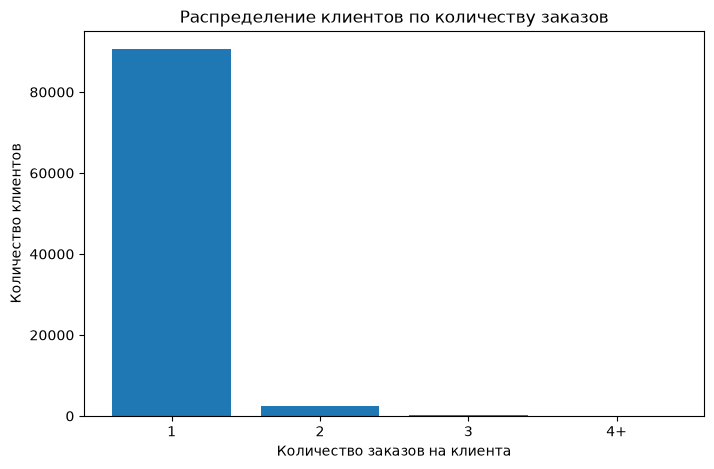

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(
    orders_per_customer_summary["orders_group"],
    orders_per_customer_summary["customers_count"]
)

plt.title("Распределение клиентов по количеству заказов")
plt.xlabel("Количество заказов на клиента")
plt.ylabel("Количество клиентов")

plt.show()

### Вывод по распределению заказов на клиента

Распределение заказов на клиента сильно смещено в сторону разовых покупок: 97% покупателей совершили только один доставленный заказ. Ещё 2.76% сделали два заказа, 0.19% — три заказа, и только 0.05% клиентов совершили четыре и более заказа.

Это подтверждает вывод о низкой повторности покупок в данных Olist. Для бизнеса это означает, что клиентская база в доступном периоде наблюдения в основном состоит из one-time buyers, а не из регулярно возвращающихся покупателей.

С продуктовой точки зрения это может указывать на потенциал для развития механик второй покупки: персональные рекомендации, реактивационные кампании, промокоды после первой покупки, улучшение клиентского опыта в категориях с высоким средним чеком и низкими отзывами.

Ограничение: мы видим только заказы внутри доступного периода данных, поэтому часть клиентов могла совершить повторные покупки уже за пределами периода наблюдения.

## Когортный анализ retention

Когортный анализ показывает, какая доля клиентов возвращается за повторными покупками через 1, 2, 3 и более месяцев после первой покупки.

Когорта определяется по месяцу первой покупки клиента. Для каждого последующего месяца считаем, сколько клиентов из этой когорты снова совершили заказ.

В этом анализе мы используем только доставленные заказы и идентификатор `customer_unique_id`.

In [12]:
cohort_data = orders_delivered.copy()

cohort_data["order_month"] = cohort_data["order_purchase_timestamp"].dt.to_period("M")

first_purchase_month = (
    cohort_data
    .groupby("customer_unique_id")["order_month"]
    .min()
    .reset_index()
    .rename(columns={"order_month": "cohort_month"})
)

cohort_data = cohort_data.merge(
    first_purchase_month,
    on="customer_unique_id",
    how="left"
)

cohort_data[["customer_unique_id", "order_id", "order_month", "cohort_month"]].head()

,customer_unique_id,order_id,order_month,cohort_month
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10,2017-09
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07,2018-07
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08,2018-08
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11,2017-11
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02,2018-02


In [13]:
cohort_data["cohort_index"] = (
    (cohort_data["order_month"].dt.year - cohort_data["cohort_month"].dt.year) * 12
    + (cohort_data["order_month"].dt.month - cohort_data["cohort_month"].dt.month)
)

cohort_data[["customer_unique_id", "order_id", "cohort_month", "order_month", "cohort_index"]].head()

,customer_unique_id,order_id,cohort_month,order_month,cohort_index
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-09,2017-10,1
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07,2018-07,0
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08,2018-08,0
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11,2017-11,0
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02,2018-02,0


In [14]:
cohort_index_check = pd.Series({
    "min_cohort_index": cohort_data["cohort_index"].min(),
    "max_cohort_index": cohort_data["cohort_index"].max(),
    "negative_cohort_index_count": (cohort_data["cohort_index"] < 0).sum()
})

cohort_index_check

min_cohort_index                0
max_cohort_index               20
negative_cohort_index_count     0
dtype: int64

In [15]:
cohort_counts = (
    cohort_data
    .groupby(["cohort_month", "cohort_index"])
    .agg(customers_count=("customer_unique_id", "nunique"))
    .reset_index()
)

cohort_counts.head()

,cohort_month,cohort_index,customers_count
0,2016-09,0,1
1,2016-10,0,262
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1


In [16]:
cohort_pivot = cohort_counts.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="customers_count"
)

cohort_sizes = cohort_pivot[0]

retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

retention_matrix.head(10)

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,0.01,0.01
2016-12,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2017-02,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
2017-03,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
2017-04,1.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN
2017-05,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN
2017-06,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN


In [17]:
retention_matrix_pct = retention_matrix * 100

retention_matrix_pct.round(2).head(10)

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.00,NaN,NaN,NaN,NaN,NaN,0.38,NaN,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,0.76,0.76
2016-12,100.00,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.00,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,NaN,0.42,0.14,0.70,0.42,0.14,0.14,0.28,0.42,0.14,NaN
2017-02,100.00,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31,0.12,0.18,0.12,0.06,0.06,0.18,NaN,NaN
2017-03,100.00,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32,0.08,0.36,0.12,0.20,0.12,0.16,0.24,0.08,0.12,NaN,NaN
2017-04,100.00,0.62,0.22,0.18,0.27,0.27,0.35,0.31,0.31,0.18,0.27,0.09,0.04,0.04,0.09,0.09,0.13,NaN,NaN,NaN
2017-05,100.00,0.46,0.46,0.29,0.29,0.32,0.41,0.14,0.26,0.26,0.26,0.35,0.23,0.03,0.17,0.20,NaN,NaN,NaN,NaN
2017-06,100.00,0.49,0.40,0.43,0.30,0.40,0.36,0.23,0.13,0.20,0.30,0.36,0.16,0.16,0.23,NaN,NaN,NaN,NaN,NaN


### Методологическая корректировка retention-матрицы

При построении retention-матрицы важно различать два случая:

- если месяц уже был доступен для наблюдения, но клиенты из когорты не вернулись, retention должен быть равен 0%;
- если месяц ещё не мог наблюдаться из-за конца периода данных, значение должно оставаться пустым.

Поэтому мы заполняем нулями только те ячейки, которые находятся внутри доступного периода наблюдения.

In [18]:
cohort_counts = (
    cohort_data
    .groupby(["cohort_month", "cohort_index"])
    .agg(customers_count=("customer_unique_id", "nunique"))
    .reset_index()
)

cohort_pivot = cohort_counts.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="customers_count"
)

max_order_month = cohort_data["order_month"].max()
max_cohort_index = cohort_data["cohort_index"].max()

cohort_pivot = cohort_pivot.reindex(columns=range(max_cohort_index + 1))

cohort_pivot_filled = cohort_pivot.copy()

for cohort_month in cohort_pivot_filled.index:
    observable_max_index = (
        (max_order_month.year - cohort_month.year) * 12
        + (max_order_month.month - cohort_month.month)
    )
    
    observable_columns = [
        column for column in cohort_pivot_filled.columns
        if column <= observable_max_index
    ]
    
    cohort_pivot_filled.loc[cohort_month, observable_columns] = (
        cohort_pivot_filled
        .loc[cohort_month, observable_columns]
        .fillna(0)
    )

cohort_sizes = cohort_pivot_filled[0]

retention_matrix = cohort_pivot_filled.divide(cohort_sizes, axis=0)
retention_matrix_pct = retention_matrix * 100

retention_matrix_pct.round(2).head(10)

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,,
2016-09,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2016-10,100.00,0.00,0.00,0.00,0.00,0.00,0.38,0.00,0.00,0.38,0.00,0.38,0.00,0.38,0.00,0.38,0.00,0.38,0.00,0.76,0.76
2016-12,100.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-01,100.00,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,0.00,0.42,0.14,0.70,0.42,0.14,0.14,0.28,0.42,0.00,0.14,NaN
2017-02,100.00,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31,0.12,0.18,0.12,0.06,0.06,0.18,0.00,NaN,NaN
2017-03,100.00,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32,0.08,0.36,0.12,0.20,0.12,0.16,0.24,0.08,0.12,NaN,NaN,NaN
2017-04,100.00,0.62,0.22,0.18,0.27,0.27,0.35,0.31,0.31,0.18,0.27,0.09,0.04,0.04,0.09,0.09,0.13,NaN,NaN,NaN,NaN
2017-05,100.00,0.46,0.46,0.29,0.29,0.32,0.41,0.14,0.26,0.26,0.26,0.35,0.23,0.03,0.17,0.20,NaN,NaN,NaN,NaN,NaN
2017-06,100.00,0.49,0.40,0.43,0.30,0.40,0.36,0.23,0.13,0.20,0.30,0.36,0.16,0.16,0.23,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
cohort_sizes_df = (
    cohort_sizes
    .reset_index()
    .rename(columns={0: "cohort_size"})
)

cohort_sizes_df.head(15)

,cohort_month,cohort_size
0,2016-09,1.00
1,2016-10,262.00
2,2016-12,1.00
3,2017-01,717.00
4,2017-02,"1,628.00"
5,2017-03,"2,503.00"
6,2017-04,"2,256.00"
7,2017-05,"3,451.00"
8,2017-06,"3,037.00"
9,2017-07,"3,752.00"


### Проверка размеров когорт

Перед интерпретацией retention важно проверить размеры когорт. Маленькие когорты могут давать визуально высокие проценты, но такие значения статистически нестабильны и плохо подходят для бизнес-выводов.

Например, когорта из одного клиента может показать 100% retention, если этот клиент сделал повторную покупку, но это не означает сильное удержание на уровне бизнеса.

Поэтому для основной retention-матрицы будем использовать только когорты достаточного размера.

In [20]:
min_cohort_size = 500
max_month_to_show = 6

valid_cohorts = cohort_sizes[cohort_sizes >= min_cohort_size].index

retention_matrix_filtered = retention_matrix_pct.loc[
    valid_cohorts,
    range(max_month_to_show + 1)
]

retention_matrix_filtered.round(2)

cohort_index,0,1,2,3,4,5,6
cohort_month,,,,,,,
2017-01,100.00,0.28,0.28,0.14,0.42,0.14,0.42
2017-02,100.00,0.18,0.31,0.12,0.43,0.12,0.25
2017-03,100.00,0.44,0.36,0.40,0.36,0.16,0.16
2017-04,100.00,0.62,0.22,0.18,0.27,0.27,0.35
2017-05,100.00,0.46,0.46,0.29,0.29,0.32,0.41
2017-06,100.00,0.49,0.40,0.43,0.30,0.40,0.36
2017-07,100.00,0.53,0.35,0.24,0.29,0.21,0.32
2017-08,100.00,0.69,0.35,0.27,0.35,0.52,0.30
2017-09,100.00,0.70,0.55,0.27,0.45,0.22,0.22


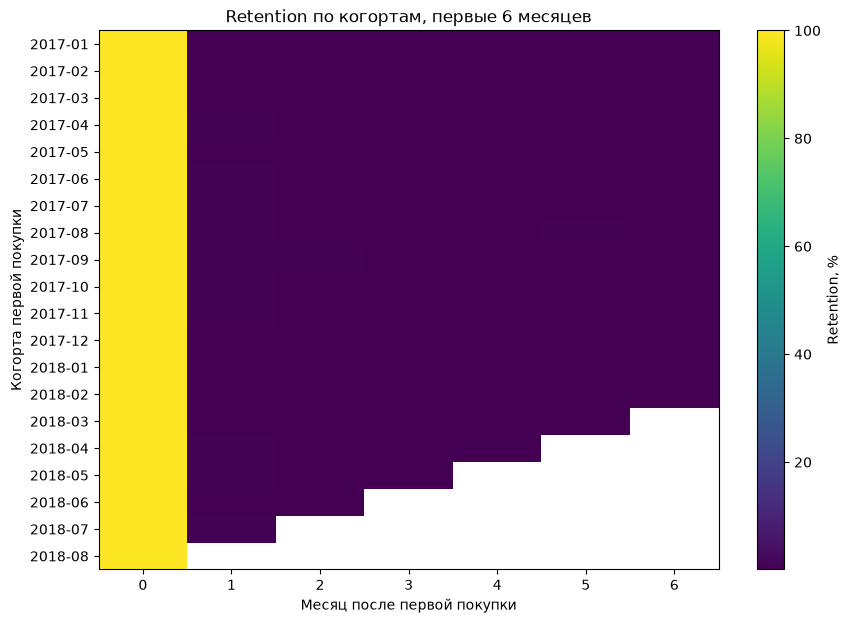

In [21]:
plt.figure(figsize=(10, 7))

plt.imshow(
    retention_matrix_filtered,
    aspect="auto"
)

plt.title("Retention по когортам, первые 6 месяцев")
plt.xlabel("Месяц после первой покупки")
plt.ylabel("Когорта первой покупки")

plt.xticks(
    ticks=range(len(retention_matrix_filtered.columns)),
    labels=retention_matrix_filtered.columns
)

plt.yticks(
    ticks=range(len(retention_matrix_filtered.index)),
    labels=retention_matrix_filtered.index.astype(str)
)

plt.colorbar(label="Retention, %")

plt.show()

### Визуализация retention без месяца первой покупки

Месяц 0 всегда равен 100%, так как это месяц первой покупки клиента. Для анализа фактического возврата клиентов важнее смотреть месяцы 1, 2, 3 и далее.

Поэтому для визуализации удержания исключим месяц 0, чтобы лучше увидеть различия между когортами после первой покупки.

In [22]:
retention_after_first_purchase = retention_matrix_filtered.loc[:, 1:6]

retention_after_first_purchase.round(2)

cohort_index,1,2,3,4,5,6
cohort_month,,,,,,
2017-01,0.28,0.28,0.14,0.42,0.14,0.42
2017-02,0.18,0.31,0.12,0.43,0.12,0.25
2017-03,0.44,0.36,0.40,0.36,0.16,0.16
2017-04,0.62,0.22,0.18,0.27,0.27,0.35
2017-05,0.46,0.46,0.29,0.29,0.32,0.41
2017-06,0.49,0.40,0.43,0.30,0.40,0.36
2017-07,0.53,0.35,0.24,0.29,0.21,0.32
2017-08,0.69,0.35,0.27,0.35,0.52,0.30
2017-09,0.70,0.55,0.27,0.45,0.22,0.22


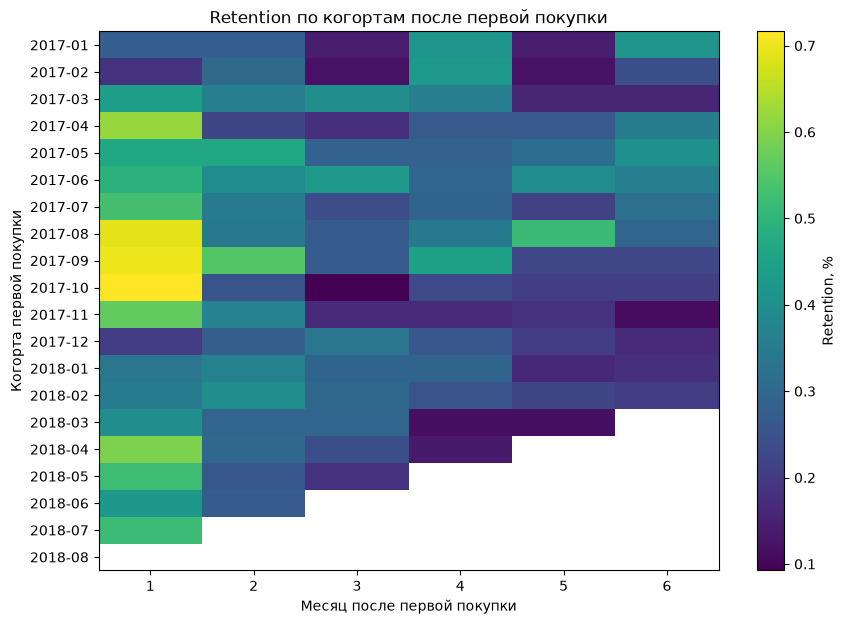

In [23]:
plt.figure(figsize=(10, 7))

plt.imshow(
    retention_after_first_purchase,
    aspect="auto"
)

plt.title("Retention по когортам после первой покупки")
plt.xlabel("Месяц после первой покупки")
plt.ylabel("Когорта первой покупки")

plt.xticks(
    ticks=range(len(retention_after_first_purchase.columns)),
    labels=retention_after_first_purchase.columns
)

plt.yticks(
    ticks=range(len(retention_after_first_purchase.index)),
    labels=retention_after_first_purchase.index.astype(str)
)

plt.colorbar(label="Retention, %")

plt.show()

In [24]:
retention_summary = (
    retention_after_first_purchase
    .mean(skipna=True)
    .reset_index()
)

retention_summary.columns = ["cohort_index", "avg_retention_pct"]

retention_summary

,cohort_index,avg_retention_pct
0,1,0.48
1,2,0.34
2,3,0.25
3,4,0.29
4,5,0.23
5,6,0.26


In [25]:
weighted_retention_summary = []

for month_index in range(1, 7):
    valid_rows = retention_matrix.loc[valid_cohorts, month_index].dropna()
    valid_sizes = cohort_sizes.loc[valid_rows.index]
    
    weighted_retention = (
        (valid_rows * valid_sizes).sum() / valid_sizes.sum() * 100
    )
    
    weighted_retention_summary.append({
        "cohort_index": month_index,
        "weighted_retention_pct": weighted_retention
    })

weighted_retention_summary = pd.DataFrame(weighted_retention_summary)

weighted_retention_summary

,cohort_index,weighted_retention_pct
0,1,0.48
1,2,0.34
2,3,0.26
3,4,0.26
4,5,0.23
5,6,0.23


### Вывод по когортному анализу

Когортный анализ подтверждает вывод о низкой повторности покупок в данных Olist. Средний weighted retention в первый месяц после первой покупки составляет около 0.48%, во второй месяц — около 0.34%, а в последующие месяцы удержание остаётся примерно на уровне 0.23–0.26%.

Важно, что взвешенный retention почти совпадает с простым средним по когортам. Это означает, что вывод о низком удержании не является следствием маленьких или нестабильных когорт, а отражает общую структуру клиентского поведения в данных.

С бизнес-точки зрения Olist в доступном периоде наблюдения выглядит как маркетплейс с высокой долей разовых покупателей. Потенциальной точкой роста могут быть механики стимулирования второй покупки: персональные рекомендации, реактивационные кампании, промокоды после первой покупки и улучшение клиентского опыта в проблемных категориях.

Ограничение: данные охватывают только исторический период 2016–2018 годов. Мы не знаем, возвращались ли клиенты после окончания периода наблюдения, и не видим маркетинговые коммуникации, которые могли влиять на повторные покупки.

## RFM-сегментация клиентов

RFM-анализ позволяет разделить клиентов на поведенческие сегменты по трём признакам:

- **Recency** — сколько дней прошло с последней покупки клиента;
- **Frequency** — сколько заказов совершил клиент;
- **Monetary** — сколько GMV принёс клиент за период наблюдения.

Такой подход помогает перейти от общей картины низкого retention к более прикладной сегментации: выделить ценных клиентов, недавних покупателей, разовых покупателей и клиентов с риском потери.

В этом проекте Monetary считается на основе `gmv`, то есть стоимости товаров без доставки.

In [26]:
snapshot_date = orders_delivered["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    orders_delivered
    .groupby("customer_unique_id")
    .agg(
        first_order_date=("order_purchase_timestamp", "min"),
        last_order_date=("order_purchase_timestamp", "max"),
        frequency=("order_id", "nunique"),
        monetary=("gmv", "sum")
    )
    .reset_index()
)

rfm["recency"] = (snapshot_date - rfm["last_order_date"]).dt.days
rfm["avg_order_value"] = rfm["monetary"] / rfm["frequency"]

rfm.head()

,customer_unique_id,first_order_date,last_order_date,frequency,monetary,recency,avg_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,129.90,112,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,18.90,115,18.90
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,69.00,537,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,25.99,321,25.99
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,180.00,288,180.00


In [27]:
rfm[["recency", "frequency", "monetary", "avg_order_value"]].describe()

,recency,frequency,monetary,avg_order_value
count,"93,358.00","93,358.00","93,358.00","93,358.00"
mean,237.94,1.03,141.62,137.51
std,152.59,0.21,215.69,209.86
min,1.00,1.00,0.85,0.85
25%,114.00,1.00,47.65,46.00
50%,219.00,1.00,89.73,86.99
75%,346.00,1.00,154.74,149.90
max,714.00,15.00,"13,440.00","13,440.00"


### Вывод по распределению RFM-признаков

RFM-признаки имеют выраженную асимметрию.

По `frequency` видно, что большинство клиентов совершили только один заказ: медиана и 75-й перцентиль равны 1. Поэтому стандартное квантильное разбиение для frequency не подходит — оно не сможет корректно разделить клиентов на 5 равных групп.

`monetary` также имеет длинный правый хвост: большинство клиентов принесли относительно небольшой GMV, но есть отдельные клиенты с очень высоким накопленным GMV.

Из-за такой структуры данных для RFM-scoring будем использовать смешанный подход:
- `recency_score` — квантильная шкала, где более недавняя покупка получает более высокий score;
- `monetary_score` — квантильная шкала, где больший GMV получает более высокий score;
- `frequency_score` — ручная шкала, так как повторных покупателей мало.

In [28]:
rfm["recency_score"] = pd.qcut(
    rfm["recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["monetary_score"] = pd.qcut(
    rfm["monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["frequency_score"] = np.select(
    [
        rfm["frequency"] == 1,
        rfm["frequency"] == 2,
        rfm["frequency"] == 3,
        rfm["frequency"] >= 4
    ],
    [
        1,
        3,
        4,
        5
    ],
    default=1
)

rfm["rfm_score"] = (
    rfm["recency_score"].astype(str)
    + rfm["frequency_score"].astype(str)
    + rfm["monetary_score"].astype(str)
)

rfm["rfm_total_score"] = (
    rfm["recency_score"]
    + rfm["frequency_score"]
    + rfm["monetary_score"]
)

rfm.head()

,customer_unique_id,first_order_date,last_order_date,frequency,monetary,recency,avg_order_value,recency_score,monetary_score,frequency_score,rfm_score,rfm_total_score
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,129.90,112,129.90,4,4,1,414,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,18.90,115,18.90,4,1,1,411,6
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,69.00,537,69.00,1,2,1,112,4
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,25.99,321,25.99,2,1,1,211,4
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,180.00,288,180.00,2,5,1,215,8


In [29]:
rfm[[
    "recency_score",
    "frequency_score",
    "monetary_score",
    "rfm_total_score"
]].describe()

,recency_score,frequency_score,monetary_score,rfm_total_score
count,"93,358.00","93,358.00","93,358.00","93,358.00"
mean,3.00,1.06,2.97,7.04
std,1.41,0.36,1.42,2.10
min,1.00,1.00,1.00,3.00
25%,2.00,1.00,2.00,6.00
50%,3.00,1.00,3.00,7.00
75%,4.00,1.00,4.00,9.00
max,5.00,5.00,5.00,15.00


### Присвоение RFM-сегментов

Из-за очень низкой повторности покупок классическая RFM-сегментация требует адаптации.

В этом датасете большинство клиентов совершили только один заказ, поэтому нельзя ожидать большого количества классических `Champions` или `Loyal Customers`. Вместо этого важно отдельно выделить:

- повторных и ценных клиентов;
- недавних one-time buyers;
- клиентов с высоким GMV;
- старых one-time buyers, которые не вернулись;
- клиентов с риском потери.

Такая сегментация лучше отражает реальную структуру клиентской базы Olist.

In [30]:
def assign_rfm_segment(row):
    if (
        row["frequency"] >= 2
        and row["recency_score"] >= 4
        and row["monetary_score"] >= 4
    ):
        return "Champions"
    
    if row["frequency"] >= 2 and row["recency_score"] >= 3:
        return "Loyal Customers"
    
    if row["frequency"] >= 2 and row["recency_score"] <= 2:
        return "At Risk Repeat Customers"
    
    if (
        row["frequency"] == 1
        and row["recency_score"] >= 4
        and row["monetary_score"] >= 4
    ):
        return "High-Value Recent One-time Buyers"
    
    if row["frequency"] == 1 and row["recency_score"] >= 4:
        return "Recent One-time Buyers"
    
    if row["frequency"] == 1 and row["monetary_score"] == 5:
        return "Big Spenders"
    
    if row["frequency"] == 1 and row["recency_score"] <= 2:
        return "Lost One-time Buyers"
    
    return "Other One-time Buyers"


rfm["segment"] = rfm.apply(assign_rfm_segment, axis=1)

rfm[[
    "customer_unique_id",
    "recency",
    "frequency",
    "monetary",
    "recency_score",
    "frequency_score",
    "monetary_score",
    "rfm_total_score",
    "segment"
]].head()

,customer_unique_id,recency,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_total_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4,9,High-Value Recent One-time Buyers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,6,Recent One-time Buyers
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2,4,Lost One-time Buyers
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1,4,Lost One-time Buyers
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,5,8,Big Spenders


In [31]:
rfm_segment_summary = (
    rfm
    .groupby("segment")
    .agg(
        customers_count=("customer_unique_id", "nunique"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        total_monetary=("monetary", "sum")
    )
    .reset_index()
)

rfm_segment_summary["customers_share_pct"] = (
    rfm_segment_summary["customers_count"]
    / rfm_segment_summary["customers_count"].sum()
    * 100
)

rfm_segment_summary["monetary_share_pct"] = (
    rfm_segment_summary["total_monetary"]
    / rfm_segment_summary["total_monetary"].sum()
    * 100
)

rfm_segment_summary = rfm_segment_summary.sort_values(
    "customers_count",
    ascending=False
)

rfm_segment_summary

,segment,customers_count,avg_recency,avg_frequency,avg_monetary,total_monetary,customers_share_pct,monetary_share_pct
4,Lost One-time Buyers,29251,394.98,1.00,75.28,"2,201,907.01",31.33,16.65
7,Recent One-time Buyers,21772,89.81,1.00,55.70,"1,212,650.08",23.32,9.17
6,Other One-time Buyers,14833,220.41,1.00,76.56,"1,135,565.46",15.89,8.59
3,High-Value Recent One-time Buyers,14452,91.84,1.00,267.80,"3,870,315.22",15.48,29.27
1,Big Spenders,10249,340.62,1.00,397.37,"4,072,651.59",10.98,30.80
0,At Risk Repeat Customers,988,382.32,2.08,246.51,"243,556.29",1.06,1.84
2,Champions,937,89.35,2.19,327.09,"306,481.81",1.00,2.32
5,Loyal Customers,876,177.61,2.07,203.62,"178,370.65",0.94,1.35


### Вывод по RFM-сегментации

RFM-сегментация подтверждает, что клиентская база Olist в доступном периоде наблюдения состоит преимущественно из one-time buyers.

Самый крупный сегмент — `Lost One-time Buyers`: 31.33% клиентов. Эти покупатели совершили один заказ давно и не вернулись в течение периода наблюдения. Однако их вклад в GMV составляет 16.65%, то есть по ценности они менее значимы, чем высокочекивые сегменты.

Особенно важны два сегмента: `Big Spenders` и `High-Value Recent One-time Buyers`. Вместе они составляют около 26% клиентов, но дают около 60% GMV. Это означает, что значительная часть оборота маркетплейса формируется не регулярными покупателями, а клиентами с одной, но дорогой покупкой.

Повторные клиенты представлены небольшими сегментами: `Champions`, `Loyal Customers` и `At Risk Repeat Customers`. В сумме они составляют около 3% клиентской базы и около 5.5% GMV. Это согласуется с предыдущими выводами о низком repeat rate и слабом retention.

С бизнес-точки зрения Olist может работать с сегментами по-разному:

- `High-Value Recent One-time Buyers` — стимулировать ко второй покупке через персональные рекомендации и предложения по связанным категориям;
- `Big Spenders` — анализировать категории дорогих покупок и запускать реактивационные кампании;
- `Champions` и `Loyal Customers` — удерживать через персональные предложения и улучшенный клиентский опыт;
- `At Risk Repeat Customers` — возвращать реактивационными механиками;
- `Lost One-time Buyers` — использовать более дешёвые массовые кампании, так как средняя ценность сегмента ниже.

Ограничение: сегмент `Lost One-time Buyers` не обязательно означает, что клиент потерян навсегда. Мы видим только период наблюдения внутри датасета и не знаем, совершал ли клиент покупки после его окончания.

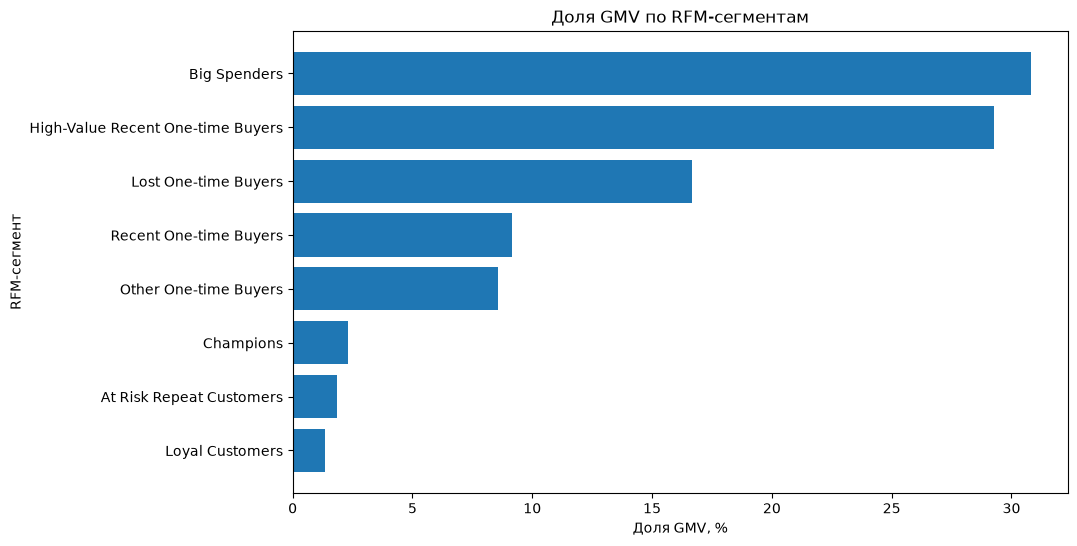

In [32]:
rfm_segment_plot = rfm_segment_summary.sort_values("monetary_share_pct", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    rfm_segment_plot["segment"],
    rfm_segment_plot["monetary_share_pct"]
)

plt.title("Доля GMV по RFM-сегментам")
plt.xlabel("Доля GMV, %")
plt.ylabel("RFM-сегмент")

plt.show()

## LTV proxy

В этом проекте мы не считаем настоящий LTV, потому что в данных нет маржи, CAC, рекламных расходов, комиссии маркетплейса и достаточно длинного периода наблюдения.

Поэтому используем более осторожную формулировку:

**LTV proxy = накопленный GMV клиента за доступный период наблюдения.**

Эта метрика показывает не прибыльность клиента, а его наблюдаемую ценность для оборота маркетплейса.

In [33]:
rfm["ltv_proxy"] = rfm["monetary"]

ltv_proxy_summary = rfm["ltv_proxy"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

ltv_proxy_summary

count   93,358.00
mean       141.62
std        215.69
min          0.85
25%         47.65
50%         89.73
75%        154.74
90%        279.99
95%        419.81
99%      1,004.99
max     13,440.00
Name: ltv_proxy, dtype: float64

In [34]:
ltv_sorted = rfm.sort_values("ltv_proxy", ascending=False).copy()

total_ltv_proxy = ltv_sorted["ltv_proxy"].sum()

top_customer_gmv_share = pd.Series({
    "top_1_pct_customers_gmv_share": (
        ltv_sorted.head(int(len(ltv_sorted) * 0.01))["ltv_proxy"].sum()
        / total_ltv_proxy
        * 100
    ),
    "top_5_pct_customers_gmv_share": (
        ltv_sorted.head(int(len(ltv_sorted) * 0.05))["ltv_proxy"].sum()
        / total_ltv_proxy
        * 100
    ),
    "top_10_pct_customers_gmv_share": (
        ltv_sorted.head(int(len(ltv_sorted) * 0.10))["ltv_proxy"].sum()
        / total_ltv_proxy
        * 100
    )
})

top_customer_gmv_share

top_1_pct_customers_gmv_share    11.46
top_5_pct_customers_gmv_share    29.13
top_10_pct_customers_gmv_share   41.10
dtype: float64

### Вывод по LTV proxy

LTV proxy, рассчитанный как накопленный GMV клиента за период наблюдения, имеет выраженное правостороннее распределение.

Медианный клиент принёс 89.73 GMV, тогда как среднее значение составляет 141.62. Это означает, что среднее значение подтягивается вверх за счёт небольшой группы клиентов с высоким накопленным GMV.

Верхние 10% клиентов формируют около 41.1% всего GMV, верхние 5% — около 29.1%, а верхний 1% — около 11.5%. Это показывает, что ценность клиентской базы распределена неравномерно: небольшая часть клиентов вносит непропорционально большой вклад в оборот маркетплейса.

С бизнес-точки зрения такие клиенты могут быть приоритетом для персональных предложений, улучшенного клиентского опыта, рекомендаций и реактивационных кампаний. Однако важно помнить, что это не настоящий LTV, а proxy-метрика на основе GMV. В данных нет маржи, CAC, комиссии маркетплейса и рекламных расходов, поэтому нельзя делать выводы о прибыльности клиентов.

In [35]:
from pathlib import Path

processed_data_path = Path("../data/processed")
processed_data_path.mkdir(parents=True, exist_ok=True)

rfm.to_csv(processed_data_path / "rfm_segments.csv", index=False)

processed_data_path / "rfm_segments.csv"

WindowsPath('../data/processed/rfm_segments.csv')

## Итоги Дня 3

В этом ноутбуке был проведён анализ повторных покупок, когортного retention, RFM-сегментации и LTV proxy для клиентов Olist.

Основные результаты:

1. Для анализа повторных покупок использовался `customer_unique_id`, так как `customer_id` в данных Olist связан с конкретным заказом и не подходит для оценки поведения одного и того же покупателя во времени.

2. Repeat purchase analysis показал, что клиентская база в доступном периоде наблюдения почти полностью состоит из разовых покупателей:
   - 97% клиентов совершили только один доставленный заказ;
   - repeat customer rate составляет около 3%;
   - среднее число заказов на клиента — 1.03.

3. Когортный анализ подтвердил низкое удержание:
   - weighted retention в первый месяц после первой покупки составляет около 0.48%;
   - во второй месяц — около 0.34%;
   - в последующие месяцы retention остаётся примерно на уровне 0.23–0.26%.

4. RFM-сегментация показала, что регулярных покупателей мало, но есть важные сегменты дорогих one-time buyers:
   - `Big Spenders`;
   - `High-Value Recent One-time Buyers`.

   Вместе эти сегменты дают значительную часть GMV, несмотря на то что не являются регулярными покупателями.

5. LTV proxy был рассчитан как накопленный GMV клиента за период наблюдения. Верхние 10% клиентов формируют около 41.1% GMV, что говорит о неравномерном распределении клиентской ценности.

Главный бизнес-вывод:

Olist в доступном периоде данных выглядит как маркетплейс с высокой долей разовых покупок и очень слабым удержанием. Рост, вероятно, сильнее зависел от привлечения новых клиентов, чем от повторных покупок существующей базы. Потенциальная точка роста — стимулирование второй покупки и персональная работа с дорогими one-time buyers.

Ключевые ограничения:

- LTV в проекте является proxy-метрикой, а не настоящим LTV;
- в данных нет маржи, CAC, рекламных расходов и комиссии маркетплейса;
- период наблюдения ограничен 2016–2018 годами;
- мы не знаем, возвращались ли клиенты после окончания датасета;
- данные не содержат маркетинговых коммуникаций и причин ухода клиентов.

In [36]:
rfm_check = pd.read_csv("../data/processed/rfm_segments.csv")

rfm_check.shape

(93358, 14)